In [1]:
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib as mpl        # Only to check the version we are working with
import matplotlib.pyplot as plt # We will be mainly using this file, instead of the whole library. That's why we give it a separated handle

       W0        W1        W2
0    -7.0  2.000000  1.000000
1    -7.0  1.978974  0.929600
2    -7.0  1.954089  0.865100
3    -7.0  1.925118  0.807621
4    -7.0  1.892061  0.757405
...   ...       ...       ...
996  -7.0 -0.201825 -0.096912
997  -7.0 -0.201825 -0.096912
998  -7.0 -0.201825 -0.096912
999  -7.0 -0.201825 -0.096912
1000 -7.0 -0.201825 -0.096912

[1001 rows x 3 columns]


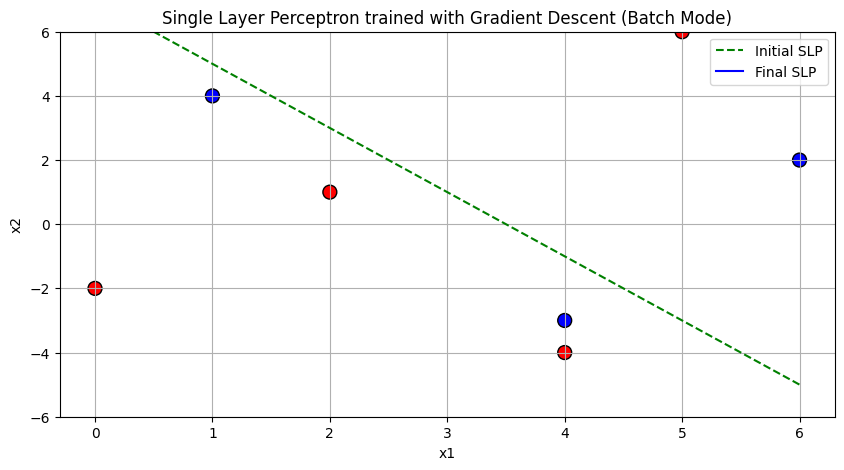

In [ ]:
# GRADIENT DESCENT SLP ALGORITHM (BATCH MODE)

# SLP parameters
alpha = 0.1 # Learning rate
max_epochs = 10 # Maxium number of iterations (epochs)

# Data
X = np.array([[0, -2], [1, 4], [2, 1], [4, -4], [4, -3], [5, 6], [6, 2]]) # Data (original)
Xt = np.c_[-1*np.ones(X.shape[0]), X] # Data with one column full of -1s (to apply the thresold, the first weight)

# Labels
y = np.array([1, -1, 1, 1, -1, 1, -1]) # Labels (original)

# Weights
W0 = [-7, 2, 1] # Initial weights
W = np.array(W0, dtype=float).copy() # Vector that we will update at each epoch
Whist = np.zeros((max_epochs,len(W0))) # Vector to save all the weights in our run

# Initial SLP
x = np.linspace(0,6,100)
SLPi = -(W0[1]/W0[2])*x - W0[0]/W0[2]

# Gradient descent algorithm
for i in range(max_epochs):
    dE = np.zeros(len(W0)) # Restart the vector where we store dE/dW (each epoch is a different value)
    for j in range(len(Xt)):
        g = np.tanh(np.clip(np.dot(Xt[j],W),-100,100))
        print(f"Epoch {i}, Sample {j}, g={g:.4f}, y={y[j]}, Error={y[j]-g:.4f}")
        
        for k in range(len(dE)):
            dE[k] += (y[j]-g) * Xt[j][k] * (1-g*g) # Notice how we are storing the values without ereasing anything until we change the epoch and update the weights (batch update)

    for l in range(len(W)):
        W[l] = W[l] + alpha*dE[l] # Update the weights (each one independently) before moving to the next epoch
    
    Whist[i] = W # Store the new values of the weights
    

Whist = np.vstack([W0, Whist]) # Add a new row at the top of Whist with the initial weights

# Table with the weights evolution
df = pd.DataFrame(Whist, columns=['W0', 'W1', 'W2'])
print(df)   